# ==============================================================

[*********************100%***********************]  2 of 2 completed


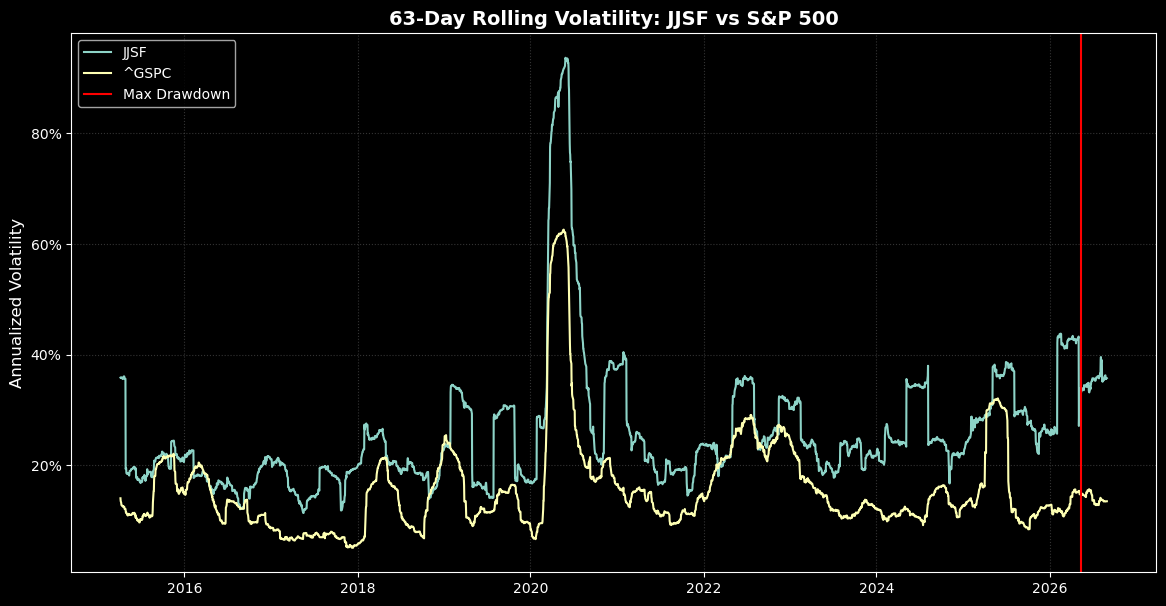

JJSF Excess Return vs S&P 500: -0.1131
Correlation (JJSF & S&P 500): 0.3996
JJSF Max Drawdown Date: 2026-05-12


In [4]:
# Imports :
import pandas as pd
import numpy as np
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Constants (Global variables):
TICKERS      = ["JJSF", "^GSPC"]
START_DATE   = "2015-01-01"
END_DATE     = "2026-09-01"
TRADING_DAYS = 252

# Function:
def get_market_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
    df = df.dropna()
    
    assert df.index.is_monotonic_increasing, "Data Error: Index is not sorted."
    assert df.isna().sum().sum() == 0, "Data Error: NaNs detected."
    
    return df

# Returns (Simple & Log) & Quant Commentary
def compute_returns(df):
    
    # Simple Return
    simple_return = df.pct_change().dropna()
    
    # Log Return
    # We use Log Returns for time-series analysis because they are time-additive and symmetric
    log_return = np.log(df / df.shift(1)).dropna()
    
    return simple_return, log_return

# Risk Profile & Benchmark Comparison
def compute_risk_profile(log_return):
    # Annualized Mean Return
    annual_return = log_return.mean() * TRADING_DAYS
    
    # Volatility scales with the square root of time
    # Annualized Volatility
    annual_volatility = log_return.std() * np.sqrt(TRADING_DAYS)
    
    return annual_return, annual_volatility

# Event Study & Max Drawdown
def compute_drawdowns(log_return):
    # Wealth Index
    wealth_index = np.exp(log_return.cumsum()) * 100
    
    # Previous Peaks
    previous_peak = wealth_index.cummax()
    
    # Drawdowns
    drawdown = (wealth_index - previous_peak) / previous_peak
    
    return wealth_index, drawdown

# Rolling Window Analysis
def compute_rolling_volatility(log_return, window=63):
    
    # Rolling Standard Deviation
    rolling_std = log_return.rolling(window=window).std()
    
    # Annualization & Drop NaNs
    annualized_rolling_volatility = (rolling_std * np.sqrt(TRADING_DAYS)).dropna()
    
    return annualized_rolling_volatility

# Main Block
if __name__ == "__main__":
    df = get_market_data(TICKERS, START_DATE, END_DATE)
    _, log_return = compute_returns(df)
    
    # Risk Profile
    annual_return, annual_volatility = compute_risk_profile(log_return)
    wealth_index, drawdowns = compute_drawdowns(log_return)
    
    # Benchmark Metrics
    jjsf_excess_return = annual_return["JJSF"] - annual_return["^GSPC"]
    
    # Correlation 
    correlation = log_return["JJSF"].corr(log_return["^GSPC"])
    
    # Data-Driven Max Drawdown
    jjsf_max_dd = drawdowns["JJSF"].min()
    jjsf_max_dd_date = drawdowns["JJSF"].idxmin()
    
    # Visual Analytics: Risk Dashboard & Max Drawdown Indicator
    rolling_vol = compute_rolling_volatility(log_return)
    plt.style.use("dark_background")
    plt.figure(figsize=(14, 7))
    plt.plot(rolling_vol.index, rolling_vol["JJSF"], label = "JJSF")
    plt.plot(rolling_vol.index, rolling_vol["^GSPC"], label = "^GSPC")
    plt.axvline(x = jjsf_max_dd_date, color = "red", label="Max Drawdown")   
    plt.title("63-Day Rolling Volatility: JJSF vs S&P 500", fontsize=14, fontweight="bold")
    plt.ylabel("Annualized Volatility", fontsize=12)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    plt.grid(color="gray", linestyle=":", alpha=0.4)
    plt.legend()
    plt.show()
    
    # Quant Commentary
    print(f"JJSF Excess Return vs S&P 500: {jjsf_excess_return:.4f}")
    print(f"Correlation (JJSF & S&P 500): {correlation:.4f}")
    print(f"JJSF Max Drawdown Date: {jjsf_max_dd_date.date()}")

# ==============================================================